# Recursive 1-Flight Rollout To 0% SOH

This notebook builds a quick `to 0%` SOH forecast using the saved best `1-flight` forecast model outputs.

Method used here:
- Start from the current causal SOH for a plane.
- Use the saved best `latent_flight_1` model behavior on evaluation rows.
- Estimate a state-conditioned per-flight SOH drop as a function of current SOH.
- Roll that forward flight by flight until SOH reaches `0%`.
- Add uncertainty bands from empirical quantiles of per-flight drop within each SOH band.

Important:
- These are **empirical rollout bands**, not fully calibrated probabilistic confidence intervals.
- Once rollout enters SOH regions with little or no evaluation support, the forecast is mostly extrapolation.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'ml_workspace').exists() and (candidate / 'frontend').exists():
            return candidate
    raise RuntimeError('Could not locate repo root from current working directory')

REPO_ROOT = find_repo_root(Path.cwd())
print('Repo root:', REPO_ROOT)

Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane


In [2]:
plane_id = '166'
bin_width_pct = 2.0
min_rows_per_bin = 12
max_rollout_flights = 5000

forecast_root = REPO_ROOT / 'ml_workspace' / 'soh_forecast' / 'output' / 'multihorizon_runner_plane_166'
kpi_path = REPO_ROOT / 'frontend' / 'public' / 'snapshots' / f'plane_{plane_id}_kpis.json'
latent_path = REPO_ROOT / 'ml_workspace' / 'latent_soh' / 'output' / f'plane_{plane_id}' / 'latent_soh_event_table.csv'

best_models = json.loads((forecast_root / 'best_models_by_horizon.json').read_text(encoding='utf-8'))
best_1 = best_models['latent_flight_1']
model_name = str(best_1['model'])
pred_path = forecast_root / 'latent_flight_1' / 'latent_flight_1_predictions.csv'

kpi_payload = json.loads(kpi_path.read_text(encoding='utf-8'))
current_soh = float(kpi_payload['health']['sohCurrent'])
replacement_date = kpi_payload['prediction']['forecast']['replacementDatePred']
rul_cycles_frontend = int(kpi_payload['prediction']['forecast']['rulCyclesPred'])

pred_df = pd.read_csv(pred_path, parse_dates=['event_datetime'])
pred_df['plane_id'] = pred_df['plane_id'].astype(str)
pred_df = pred_df.loc[pred_df['plane_id'].eq(plane_id)].copy()
pred_df['current_soh'] = pd.to_numeric(pred_df['latent_soh_filter_pct'], errors='coerce')
pred_df['predicted_soh'] = pd.to_numeric(pred_df[model_name], errors='coerce')
pred_df['per_flight_drop'] = pred_df['predicted_soh'] - pred_df['current_soh']
pred_df['target_soh'] = pd.to_numeric(pred_df['next_latent_soh_causal_flight_1_pct'], errors='coerce')
pred_df['residual'] = pred_df['target_soh'] - pred_df['predicted_soh']
pred_df['is_eval'] = pred_df['split'].isin(['valid', 'test', 'holdout'])

eval_df = pred_df.loc[pred_df['is_eval']].copy()
eval_df = eval_df.replace([np.inf, -np.inf], np.nan)
eval_df = eval_df.dropna(subset=['current_soh', 'predicted_soh', 'per_flight_drop'])
eval_df = eval_df.loc[eval_df['per_flight_drop'] < 0].copy()

latent_df = pd.read_csv(latent_path, parse_dates=['event_datetime'])

print(f'Plane: {plane_id}')
print(f'Best 1-flight model: {model_name}')
print(f'Current SOH: {current_soh:.3f}%')
print(f'Frontend RUL cycles: {rul_cycles_frontend}')
print(f'Frontend replacement date: {replacement_date}')
print(f'1-flight eval rows available: {len(eval_df)}')
print(f'Eval SOH support range: {eval_df["current_soh"].min():.3f}% to {eval_df["current_soh"].max():.3f}%')

Plane: 166
Best 1-flight model: random_forest_with_latent
Current SOH: 57.622%
Frontend RUL cycles: 243
Frontend replacement date: 2027-04-07
1-flight eval rows available: 261
Eval SOH support range: 55.814% to 78.638%


In [3]:
bin_edges = np.arange(
    math.floor(eval_df['current_soh'].min()),
    math.ceil(eval_df['current_soh'].max()) + bin_width_pct,
    bin_width_pct,
)
eval_df['soh_bin'] = pd.cut(eval_df['current_soh'], bins=bin_edges, include_lowest=True)

band_df = (
    eval_df.groupby('soh_bin', observed=False)
    .agg(
        soh_mid=('current_soh', 'median'),
        drop_p10=('per_flight_drop', lambda s: float(np.nanquantile(s, 0.10))),
        drop_p50=('per_flight_drop', 'median'),
        drop_p90=('per_flight_drop', lambda s: float(np.nanquantile(s, 0.90))),
        residual_std=('residual', 'std'),
        n=('per_flight_drop', 'size'),
    )
    .dropna(subset=['soh_mid', 'drop_p10', 'drop_p50', 'drop_p90'])
    .reset_index(drop=True)
)
supported_band_df = band_df.loc[band_df['n'] >= min_rows_per_bin].copy()
min_supported_soh = float(supported_band_df['soh_mid'].min()) if not supported_band_df.empty else np.nan
max_supported_soh = float(supported_band_df['soh_mid'].max()) if not supported_band_df.empty else np.nan

support_table = pd.DataFrame(
    [
        {'metric': 'current_soh', 'value': current_soh},
        {'metric': 'min_supported_soh', 'value': min_supported_soh},
        {'metric': 'max_supported_soh', 'value': max_supported_soh},
        {'metric': 'lowest_historical_filter_soh', 'value': float(latent_df['latent_soh_filter_pct'].min())},
        {'metric': 'lowest_historical_flight_filter_soh', 'value': float(latent_df.loc[latent_df['event_type'].eq('flight'), 'latent_soh_filter_pct'].min())},
        {'metric': 'n_supported_bands', 'value': float(len(supported_band_df))},
    ]
)

support_table

,metric,value
0,current_soh,57.621574
1,min_supported_soh,66.009764
2,max_supported_soh,77.780628
3,lowest_historical_filter_soh,54.557574
4,lowest_historical_flight_filter_soh,55.173113
5,n_supported_bands,5.000000


In [4]:
def state_drop_quantiles(soh: float) -> tuple[float, float, float]:
    if supported_band_df.empty:
        return (-0.12, -0.09, -0.06)

    x = supported_band_df['soh_mid'].to_numpy(dtype=float)
    q10 = supported_band_df['drop_p10'].to_numpy(dtype=float)
    q50 = supported_band_df['drop_p50'].to_numpy(dtype=float)
    q90 = supported_band_df['drop_p90'].to_numpy(dtype=float)

    if soh <= x.min():
        return float(q10[0]), float(q50[0]), float(q90[0])
    if soh >= x.max():
        return float(q10[-1]), float(q50[-1]), float(q90[-1])

    return (
        float(np.interp(soh, x, q10)),
        float(np.interp(soh, x, q50)),
        float(np.interp(soh, x, q90)),
    )

def rollout_curve(start_soh: float, which: str) -> pd.DataFrame:
    rows = []
    soh = float(start_soh)
    flight = 0

    while soh > 0 and flight < max_rollout_flights:
        drop_p10, drop_p50, drop_p90 = state_drop_quantiles(soh)
        chosen_drop = {'p10': drop_p10, 'p50': drop_p50, 'p90': drop_p90}[which]
        rows.append(
            {
                'flight_ahead': flight,
                'soh': soh,
                'drop': chosen_drop,
                'supported': bool(min_supported_soh <= soh <= max_supported_soh) if np.isfinite(min_supported_soh) else False,
            }
        )
        soh = max(0.0, soh + chosen_drop)
        flight += 1

    rows.append(
        {
            'flight_ahead': flight,
            'soh': soh,
            'drop': np.nan,
            'supported': bool(min_supported_soh <= soh <= max_supported_soh) if np.isfinite(min_supported_soh) else False,
        }
    )
    return pd.DataFrame(rows)

curve_fast = rollout_curve(current_soh, 'p10')
curve_median = rollout_curve(current_soh, 'p50')
curve_slow = rollout_curve(current_soh, 'p90')

summary = pd.DataFrame(
    [
        {'scenario': 'faster degradation (p10 drop)', 'flights_to_zero': int(curve_fast['flight_ahead'].iloc[-1])},
        {'scenario': 'median degradation (p50 drop)', 'flights_to_zero': int(curve_median['flight_ahead'].iloc[-1])},
        {'scenario': 'slower degradation (p90 drop)', 'flights_to_zero': int(curve_slow['flight_ahead'].iloc[-1])},
    ]
)

summary

,scenario,flights_to_zero
0,faster degradation (p10 drop),185
1,median degradation (p50 drop),237
2,slower degradation (p90 drop),608


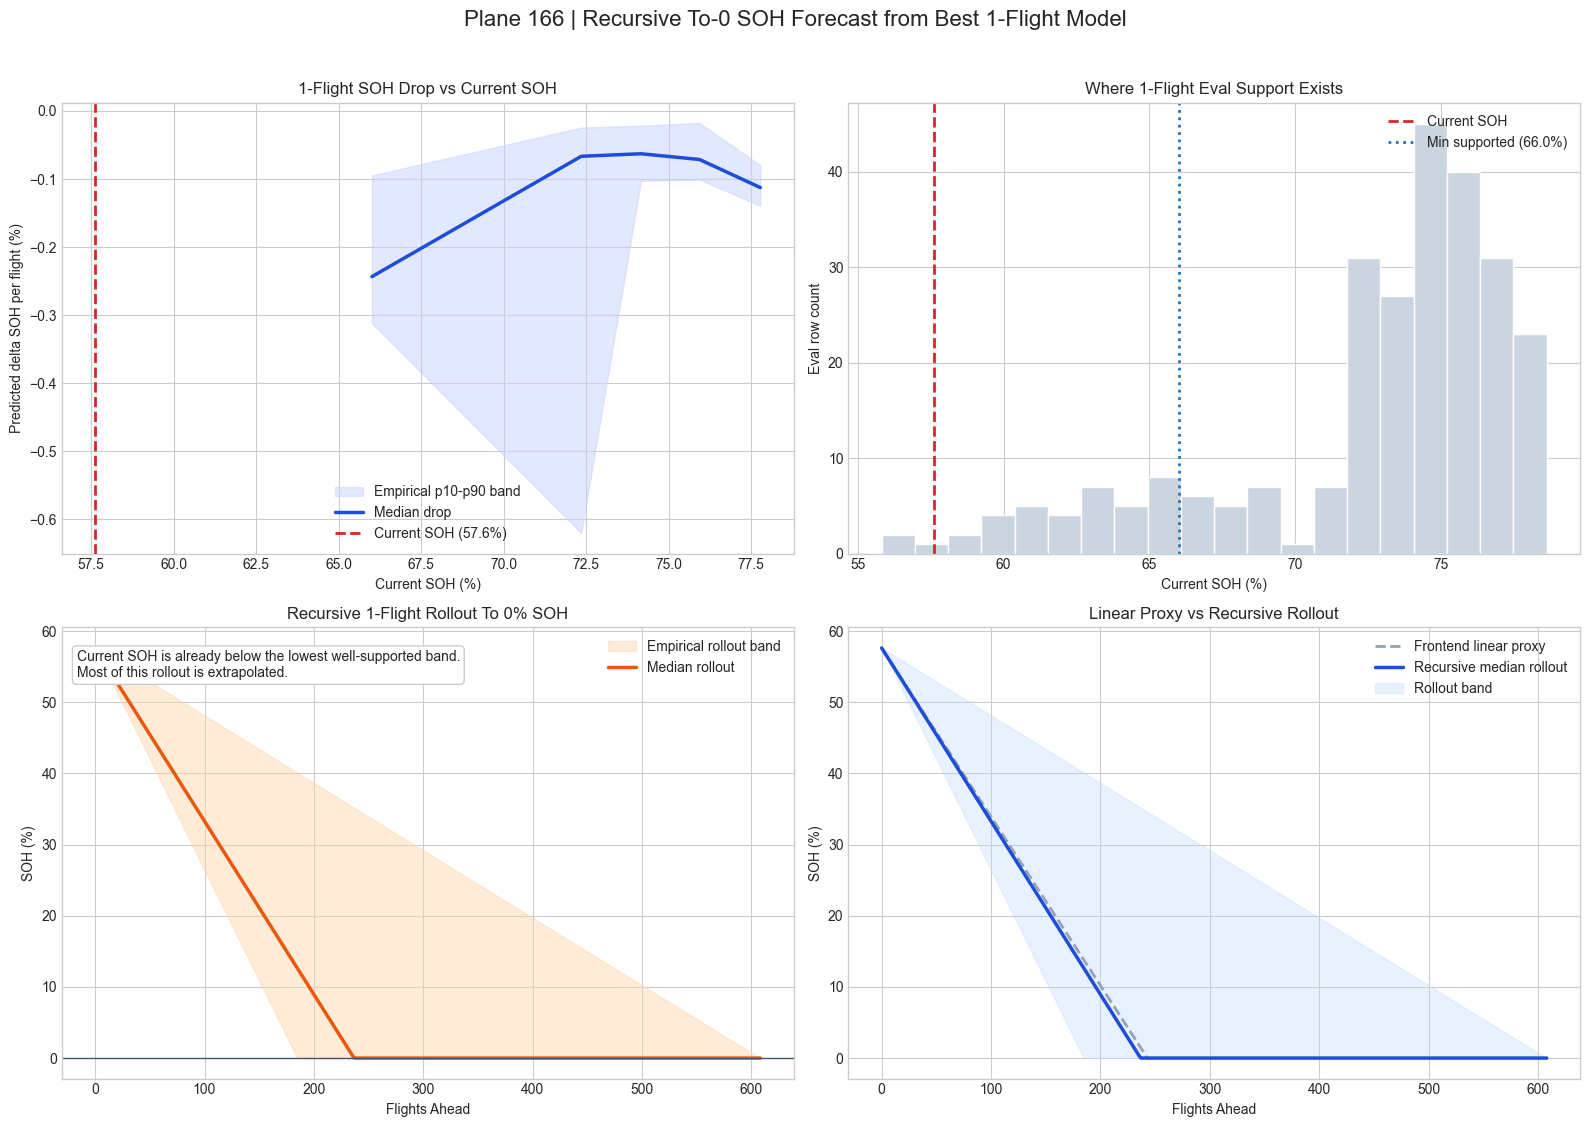

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1) State-conditioned drop bands
axes[0, 0].fill_between(
    supported_band_df['soh_mid'],
    supported_band_df['drop_p10'],
    supported_band_df['drop_p90'],
    color='#c7d2fe',
    alpha=0.5,
    label='Empirical p10-p90 band',
)
axes[0, 0].plot(supported_band_df['soh_mid'], supported_band_df['drop_p50'], color='#1d4ed8', linewidth=2.5, label='Median drop')
axes[0, 0].axvline(current_soh, color='tab:red', linestyle='--', linewidth=2, label=f'Current SOH ({current_soh:.1f}%)')
axes[0, 0].set_title('1-Flight SOH Drop vs Current SOH')
axes[0, 0].set_xlabel('Current SOH (%)')
axes[0, 0].set_ylabel('Predicted delta SOH per flight (%)')
axes[0, 0].legend(loc='best')

# 2) Support histogram
axes[0, 1].hist(eval_df['current_soh'], bins=20, color='#cbd5e1', edgecolor='white')
axes[0, 1].axvline(current_soh, color='tab:red', linestyle='--', linewidth=2, label='Current SOH')
if np.isfinite(min_supported_soh):
    axes[0, 1].axvline(min_supported_soh, color='tab:blue', linestyle=':', linewidth=2, label=f'Min supported ({min_supported_soh:.1f}%)')
axes[0, 1].set_title('Where 1-Flight Eval Support Exists')
axes[0, 1].set_xlabel('Current SOH (%)')
axes[0, 1].set_ylabel('Eval row count')
axes[0, 1].legend(loc='best')

# 3) Recursive rollout with uncertainty band
common_max = max(
    int(curve_fast['flight_ahead'].iloc[-1]),
    int(curve_median['flight_ahead'].iloc[-1]),
    int(curve_slow['flight_ahead'].iloc[-1]),
)
common_index = np.arange(common_max + 1)
fast_interp = np.interp(common_index, curve_fast['flight_ahead'], curve_fast['soh'])
median_interp = np.interp(common_index, curve_median['flight_ahead'], curve_median['soh'])
slow_interp = np.interp(common_index, curve_slow['flight_ahead'], curve_slow['soh'])

upper = np.maximum(fast_interp, slow_interp)
lower = np.minimum(fast_interp, slow_interp)

axes[1, 0].fill_between(common_index, lower, upper, color='#fed7aa', alpha=0.45, label='Empirical rollout band')
axes[1, 0].plot(common_index, median_interp, color='#ea580c', linewidth=2.5, label='Median rollout')
axes[1, 0].axhline(0, color='#475569', linewidth=1)
if np.isfinite(min_supported_soh) and current_soh < min_supported_soh:
    axes[1, 0].text(
        0.02,
        0.95,
        'Current SOH is already below the lowest well-supported band.\nMost of this rollout is extrapolated.',
        transform=axes[1, 0].transAxes,
        va='top',
        bbox=dict(boxstyle='round', fc='white', ec='0.8'),
    )
axes[1, 0].set_title('Recursive 1-Flight Rollout To 0% SOH')
axes[1, 0].set_xlabel('Flights Ahead')
axes[1, 0].set_ylabel('SOH (%)')
axes[1, 0].legend(loc='best')

# 4) Compare to frontend linear proxy
linear_curve = pd.DataFrame(
    {
        'flight_ahead': np.arange(rul_cycles_frontend + 1, dtype=int),
        'soh': np.linspace(current_soh, 0.0, rul_cycles_frontend + 1),
    }
)
axes[1, 1].plot(linear_curve['flight_ahead'], linear_curve['soh'], color='#94a3b8', linewidth=2.0, linestyle='--', label='Frontend linear proxy')
axes[1, 1].plot(common_index, median_interp, color='#1d4ed8', linewidth=2.5, label='Recursive median rollout')
axes[1, 1].fill_between(common_index, lower, upper, color='#bfdbfe', alpha=0.35, label='Rollout band')
axes[1, 1].set_title('Linear Proxy vs Recursive Rollout')
axes[1, 1].set_xlabel('Flights Ahead')
axes[1, 1].set_ylabel('SOH (%)')
axes[1, 1].legend(loc='best')

fig.suptitle(f'Plane {plane_id} | Recursive To-0 SOH Forecast from Best 1-Flight Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## How to read this notebook

- The **drop-vs-state plot** shows how the saved best `1-flight` model behaves across SOH states on evaluation rows.
- The **rollout band** comes from empirical `p10 / p50 / p90` per-flight degradation within SOH bands.
- If the current SOH is below the supported region, the `to 0%` forecast is mostly extrapolation.

This is still a better `to 0%` view than repeatedly applying a 30-day model, because it uses the shortest-step transition model available.

If you want the next step after this notebook, the right implementation is:
- recursive rollout from actual saved model artifacts and live feature recomputation,
- plus schedule assumptions to convert flights to calendar replacement date.